In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    cross_val_predict,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, f1_score

import seaborn as sns



## Ansvarsområden:
-   Data & EDA -Victoria
-   Pipeline & preprocessing -Elisabeth
-   Modelljämförelse -Victoria
-   Optimering  - Anarkoli
-   Threshold/prioritering 
-   Pitch & risker 

## EDA
-   Datastorlek 12 000 rader, 18 kolumner
-   Datatyper: 9 numeriska och 8 kategoriska kolumner + target.
-   Targetfördelning: is_suspicious 10,2 %
-   Missingvalue konstaterades i två numeriska kolumner där ett missingvalue ersätts med median och en kategorisk kolumn där missingvalue hanteras som en egen kategori.
-   Data i korrelationsmatris visar ingen enskild feature som har stark linjär relation.
-   En variabel visade korrelation över abs(0,1) och undersöktes vidare med violinplot, där tidigare misstänkta incidenter i större  utsträckning fanns i gruppen is_suspicious.

In [4]:
df = pd.read_csv("historical_data.csv")

target_column_name = "is_suspicious" 
feature_column_names = [col for col in df.columns if col != target_column_name]

# Info
print("\nDataset information: ")
df.info()

numeric_features = ["day", 
                    "account_age_days", "num_prev_listings", 
                    "prev_reports_30d",
                    "price", "num_images",
                    "message_length",
                    "time_to_first_response_min"]
categorical_features = ["event_type", "category", "region", "device", "contains_off_platform",
                    "urgency_words", "verification_level", "payment_attempt"]


# Target-fördelning
print(df[target_column_name].value_counts(normalize=True) * 100)


Dataset information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  object 
 3   category                    12000 non-null  object 
 4   region                      11660 non-null  object 
 5   device                      12000 non-null  object 
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  contains

In [5]:
# Kategorisk analys

print("\nKategoriska värden:")
for col in categorical_features:
    print(f"\nKolumn: {col}")
    print(df[col].value_counts())
    print("Antal unika värden:", df[col].nunique())



Kategoriska värden:

Kolumn: event_type
ad_post         8535
message_send    3465
Name: event_type, dtype: int64
Antal unika värden: 2

Kolumn: category
other          2850
furniture      2208
electronics    2173
bikes          1922
phones         1475
fashion        1372
Name: category, dtype: int64
Antal unika värden: 6

Kolumn: region
metro    5219
urban    4095
rural    2346
Name: region, dtype: int64
Antal unika värden: 3

Kolumn: device
android    6616
ios        4160
web        1224
Name: device, dtype: int64
Antal unika värden: 3

Kolumn: contains_off_platform
0    11126
1      874
Name: contains_off_platform, dtype: int64
Antal unika värden: 2

Kolumn: urgency_words
0    10811
1     1189
Name: urgency_words, dtype: int64
Antal unika värden: 2

Kolumn: verification_level
0    5346
1    4786
2    1868
Name: verification_level, dtype: int64
Antal unika värden: 3

Kolumn: payment_attempt
0    9826
1    2174
Name: payment_attempt, dtype: int64
Antal unika värden: 2


In [6]:
# Saknade värden

print("Missing values i hela datasetet:")
print(df.isna().sum().sort_values(ascending=False))



Missing values i hela datasetet:
price                         818
time_to_first_response_min    590
region                        340
id                              0
payment_attempt                 0
urgency_words                   0
contains_off_platform           0
message_length                  0
num_images                      0
verification_level              0
day                             0
prev_reports_30d                0
num_prev_listings               0
account_age_days                0
device                          0
category                        0
event_type                      0
is_suspicious                   0
dtype: int64


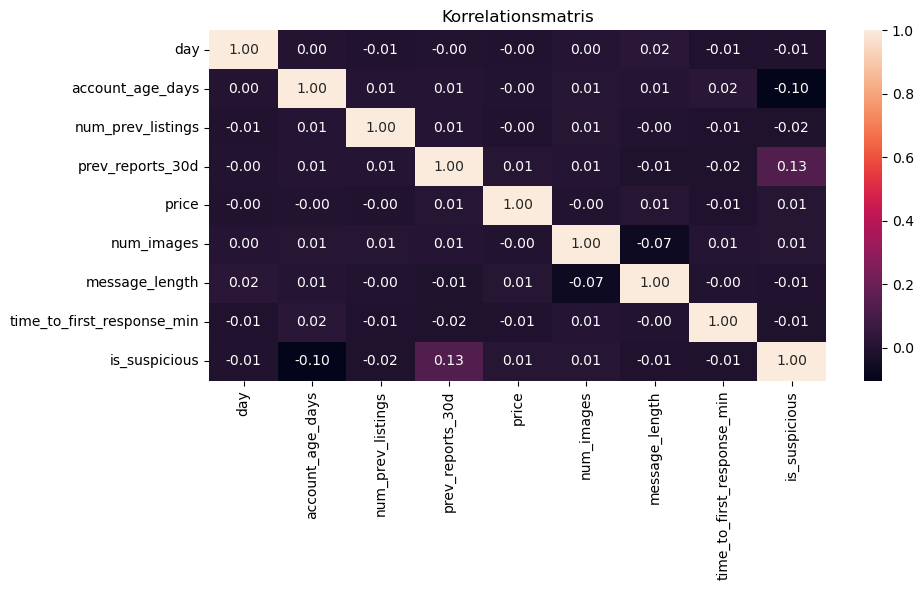

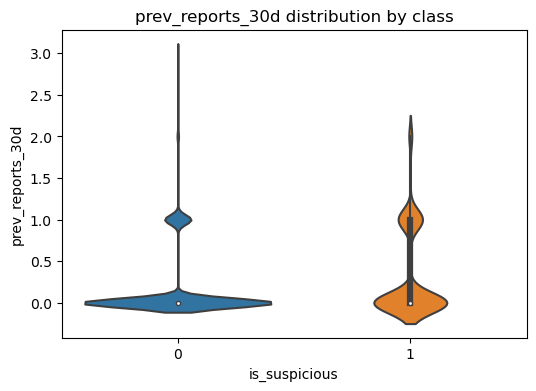

In [7]:
#Heatmap
fig, ax = plt.subplots(figsize=(10, 6))

features_numeric_target = numeric_features + ["is_suspicious"]

corr = df[features_numeric_target].corr()
sns.heatmap(corr, annot=True, fmt=".2f", ax=ax)
ax.set_title("Korrelationsmatris")
plt.tight_layout()
plt.show()




features_from_corr = ["prev_reports_30d"]
for feature in features_from_corr:
    plt.figure(figsize=(6,4))
    
    sns.violinplot(x="is_suspicious", y=feature, data=df)
    
    plt.title(f"{feature} distribution by class")
    plt.show()

# plt.title("Distribution of Previous Reports by Suspicion Class")
# plt.show()

# Train/ test split

Vi lämnar 20% till testdata och tar med oss överiga 80% till vår CV.
Vi gjorde en stratify utifrån y för att försäkra oss om att target värden kommer med i träningsdatan. (Obalansen består av att is_suspicious = True är endast 10%)
Vi skapade en pipeline där numeriska och kategoriska värden kombineras


In [8]:
X_full = df[feature_column_names]
y_full = df[target_column_name]

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,        # reproducerbarhet
    stratify=y_full         # stratify då target är obalanserad
)

X_test.shape

(2400, 17)

In [9]:
# Pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",        #ignorerar om ny, okänd data kommer i testdatan
        sparse_output=False             #sparse för att det låter bra
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)


# Baseline
Vi valde att göra baseline på Stratify, vilket gav oss en Accuracy på 0.82, en Precision, Recall och F1 hamnade alla på 0.10, vilket motsvarade den stratifierade uppdelningen av Target (ca 10%). 
Vi prövade även en baseline på Most Frequent. Den gav en Accurancy på 0.90 men en Precision, Recall och F1 på 0, vilket betydde att predictionen alltid är "icke misstänkt" och inga bedrägeriförsök upptäcks. Det visar även varför Accuracy är en sämre metric på obalanserade dataset. 

In [10]:

baseline_model = DummyClassifier(strategy="stratified", random_state=42)

# fit baseline
baseline_model.fit(X_train, y_train)
      
y_test_predict = baseline_model.predict(X_test)

print("DummyClassifier baseline (test)")
print("Accuracy :", accuracy_score(y_test, y_test_predict))
print("Precision:", precision_score(y_test, y_test_predict, zero_division=0))
print("Recall   :", recall_score(y_test, y_test_predict, zero_division=0))
print("F1       :", f1_score(y_test, y_test_predict, zero_division=0))


DummyClassifier baseline (test)
Accuracy : 0.82
Precision: 0.10548523206751055
Recall   : 0.10204081632653061
F1       : 0.1037344398340249


## Träna modeller

Vi valde att träna två modeller:
-   Logistic Regression som är en enkel modell och lätt att tolka
-   Random Forest som är en mer avancerad modell som har lättar att fånga komplexa mönster. 

Givet vårt kravkort vill vi:
-   minimera onödiga flaggningar alltså maximera Precision
-   flaggningar känns konsekventa och rimliga

Resultat (utvärdering med CV): 
-   Baserat på att maximera Precision så presterar Logistic Regression bäst. 

In [11]:
#Pipeline för modeller

log_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])


rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier( #lägg till max_depth om det tar lång tid att köra
        n_estimators=200,
        random_state=42,
        n_jobs=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "precision" #pga kravkort

In [12]:

scoring = ["accuracy", "precision", "recall", "f1"]
# Accuracy = hur stor andel av alla prediktioner som är rätt. (TP + TN)/(Tp + TN+ FP + FN)
# Precision = hur många av de positiva prediktionerna som faktiskt är rätt. =TP/(TP+FP)
# Recall = hur många av de verkliga positiva som modellen hittar. =TP/(TP+FN)

models = {
    "DummyClassifier": baseline_model,
    "LogisticRegression": log_reg,
    "RandomForest": rf,
}

results = {}

for name, model in models.items():
    
    cv_results = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    
    results[name] = {
        "accuracy": cv_results["test_accuracy"].mean(),
        "precision": cv_results["test_precision"].mean(),
        "recall": cv_results["test_recall"].mean(),
        "f1": cv_results["test_f1"].mean()
    }

df_results = pd.DataFrame(results).T
print(df_results.round(3))

                    accuracy  precision  recall     f1
DummyClassifier        0.815      0.095   0.095  0.095
LogisticRegression     0.899      0.593   0.044  0.081
RandomForest           0.899      0.543   0.021  0.041


In [13]:
model_rows = []

for name, pipe in [("LogisticRegression", log_reg), ("RandomForest", rf), ("Baseline", baseline_model)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING)
    model_rows.append({"model": name, "mean": scores.mean(), "std": scores.std()})

models_table = pd.DataFrame(model_rows).sort_values("mean", ascending=False)
models_table

,model,mean,std
0,LogisticRegression,0.624491,0.124410
1,RandomForest,0.548175,0.130161
2,Baseline,0.092779,0.018717


## Optimering(Hyperparameter Tuning)


Vi tunade Logistic Regression model på två hyperparametrar:
- **C** (Regulariseringsstyrka) 
- **class_weight** (Justerar för klassobalans).

GridSearchCV användes för att testa olika värden för de logistiska regressionsparametrar C och class_weight för att  optimerar **Precision** och anpassa sig till kravkort (minimerar onödiga flaggor).

Den bästa kombinationen var:
- C = 0.03
- class_weight = None

Detta ger en korsvaliderad **Precision** på **≈66 %**, vilket innebär att ungefär två tredjedelar av flaggade händelser är verkligt misstänkta. Modellen är konservativ och undviker aggressiv flaggning.

In [14]:
chosen_model_name = "LogisticRegression"
print("Vi tunar:", chosen_model_name)


pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

# Hyperparameter grid
param_grid = {
    "model__C": [0.01, 0.02, 0.03, 0.04],                # mindre/större regularisering
    "model__class_weight": [None, "balanced"] # testa lite omviktning
}

# Grid search med Stratified CV och precision som scoring
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="precision",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


# Bäst parameters och score
print("Bäst hyperparameters:", grid_search.best_params_)
print("Bäst CV precision:", grid_search.best_score_)


Vi tunar: LogisticRegression
Bäst hyperparameters: {'model__C': 0.03, 'model__class_weight': None}
Bäst CV precision: 0.6795238095238096


## Threshold / Prioritering

I detta steg bestämmer vi hur modellen ska användas i praktiken för att flagga misstänkta händelser.

Modellen ger en sannolikhet för att en observation är suspicious. För att fatta ett beslut behöver vi därför sätta en **threshold**, alltså en gräns för när en observation ska flaggas.

Eftersom vårt kravkort fokuserar på att **minimera onödiga flaggningar och göra flaggningar rimliga**, testar vi flera olika threshold-värden och analyserar hur de påverkar:

- precision
- recall
- antal flaggade fall
- false positives och false negatives

Målet är att välja en threshold som passar stakeholderns behov.

In [16]:
# Hämta den bästa modellen från grid search
best_model = grid_search.best_estimator_

# Prediktera sannolikheten att en observation är suspicious
y_proba = best_model.predict_proba(X_test)[:, 1]

# Visa några exempel på sannolikheter
print("Example probabilities:", y_proba[:10])

Example probabilities: [0.12244815 0.05083594 0.09522554 0.0156595  0.0929612  0.04147829
 0.25614925 0.10233498 0.0685028  0.12260019]


In [17]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import pandas as pd

# thresholds vi vill testa
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

results = []

for t in thresholds:
    
    # skapa prediction baserat på threshold
    y_pred = (y_proba >= t).astype(int)
    
    # confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    results.append({
        "threshold": t,
        "flagged_cases": y_pred.sum(),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "false_positives": fp,
        "false_negatives": fn
    })

threshold_df = pd.DataFrame(results)
threshold_df

,threshold,flagged_cases,precision,recall,false_positives,false_negatives
0,0.3,77,0.402597,0.126531,46,214
1,0.4,28,0.571429,0.065306,12,229
2,0.5,8,0.500000,0.016327,4,241
3,0.6,5,0.400000,0.008163,3,243
4,0.7,1,0.000000,0.000000,1,245
5,0.8,0,0.000000,0.000000,0,245


In [18]:
chosen_threshold = 0.4

y_pred_final = (y_proba >= chosen_threshold).astype(int)

from sklearn.metrics import confusion_matrix, precision_score, recall_score

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

print("Chosen threshold:", chosen_threshold)
print("Flagged cases:", y_pred_final.sum())
print("Precision:", precision_score(y_test, y_pred_final, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_final, zero_division=0))
print("False positives:", fp)
print("False negatives:", fn)

Chosen threshold: 0.4
Flagged cases: 28
Precision: 0.5714285714285714
Recall: 0.0653061224489796
False positives: 12
False negatives: 229


### Val av threshold

Modellen ger en sannolikhet för att en händelse är suspicious. För att kunna använda modellen i praktiken behöver man därför sätta en threshold, alltså en gräns för när något ska flaggas.

En vanlig standard i många klassificeringsproblem är att använda en threshold på **0.5**, vilket innebär att modellen flaggar en observation om sannolikheten är högre än 50 %. Vi valde dock att inte automatiskt använda denna standard utan istället testa flera olika thresholds och se hur de påverkar precision, recall och antal flaggade fall.

När threshold är låg flaggas fler händelser, men risken för false positives ökar. När threshold är hög blir modellen mer försiktig, men då missar den också fler verkligt misstänkta fall.

Eftersom vårt kravkort fokuserar på att minimera onödiga flaggningar valde vi att prioritera precision. I vår analys gav **0.4** den högsta precisionen samtidigt som modellen fortfarande identifierar vissa misstänkta fall. Därför valde vi att använda en threshold på **0.4** i den slutliga modellen.